# G1 standup — algorithm bake-off

Closed-loop Unitree G1 standup (29 actuators): drive the torso upright and to target height while staying near the nominal stand pose. Same harness and algorithms as the other env notebooks.

In [1]:
# Always pick up the latest code in analytic_mppi/ (incl. experimental.py)
# without restarting the kernel — edit a .py, re-run a cell, done.
%load_ext autoreload
%autoreload 2

import numpy as np
from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.eval import (
    Config, run_study, plot_study, summarize, render_video,
    g1_metrics, g1_panels, g1_metrics, g1_panels
)
# Controllers are imported straight from the package (autoreloaded):
from analytic_mppi.controllers import MPPIv2, MppiCma, CEM, DIAL, PredictiveSampling
from analytic_mppi.controllers.experimental import UniformGD, GaussianGD, RankCMA, FplValueCMA

TASK = "g1_standup"
task = make_task(TASK)
DT = MujocoBackend(task.model_path).dt
print(f"task={TASK}  nq={task.nq} nv={task.nv} nu={task.nu} dt={DT}")

task=g1_standup  nq=36 nv=35 nu=29 dt=0.02


## Experiment configuration

Each `Config` is one row: a label, the controller **class** (imported above), the cost mode, and its algo kwargs. Shared sampler settings apply to every row.

> **Initial pose:** this starts from the model's default `qpos0`. To study standing up from a specific pose, set an `init_fn=...` that writes a keyframe (e.g. mirror `run.py`'s `stand`, or a fallen pose) before the run.

In [2]:
# g1 is 29-DOF and expensive; keep K / steps modest in the template and scale up as needed
SHARED = dict(num_samples=64, plan_horizon=0.5, num_knots=4)

CONFIGS = [
    Config("mppi  (normal)",          MPPIv2,       "normal",         dict(noise_level=0.3, temperature=0.1)),
    Config("mppi_cma  (normal)",      MppiCma,      "normal",         dict(initial_noise_level=0.5, temperature=0.1, minimum_noise_level=0.1)),
    Config("mppi  (fpl)",             MPPIv2,       "fpl_discounted", dict(noise_level=0.3, temperature=0.1)),
    Config("uniform_gd  (fpl)",       UniformGD,    "fpl_discounted", dict(noise_level=0.5, n_gd_iter=5)),
    Config("gaussian_gd  (fpl)",      GaussianGD,   "fpl_discounted", dict(noise_level=0.3, n_gd_iter=5)),
    Config("rank_cma  (fpl)",         RankCMA,      "fpl_discounted", dict(sigma_init=0.5, n_gd_iter=5)),
    Config("fpl_value_cma  (fpl)",    FplValueCMA,  "fpl_discounted", dict(sigma_init=0.5, beta=10.0, n_gd_iter=5)),
]

## Run the closed-loop study

Fresh MuJoCo sim per (config, episode); mean ± 1 std bands across episodes.

running mppi  (normal)                          .. done
running mppi_cma  (normal)                      .. done
running mppi  (fpl)                             .. done
running uniform_gd  (fpl)                       .. done
running gaussian_gd  (fpl)                      .. done
running rank_cma  (fpl)                         .. done
running fpl_value_cma  (fpl)                    .. done
config                                      height_err       upright         u_mag
mppi  (normal)                                  0.1750        0.4991        0.7401
mppi_cma  (normal)                              0.3139        0.2498        0.7243
mppi  (fpl)                                     0.2684        0.8742        0.9081
uniform_gd  (fpl)                               0.2556        0.9058        0.8905
gaussian_gd  (fpl)                              0.2479        0.9105        0.8785
rank_cma  (fpl)                                 0.2304        0.9457        0.5996
fpl_value_cma  (fpl)       

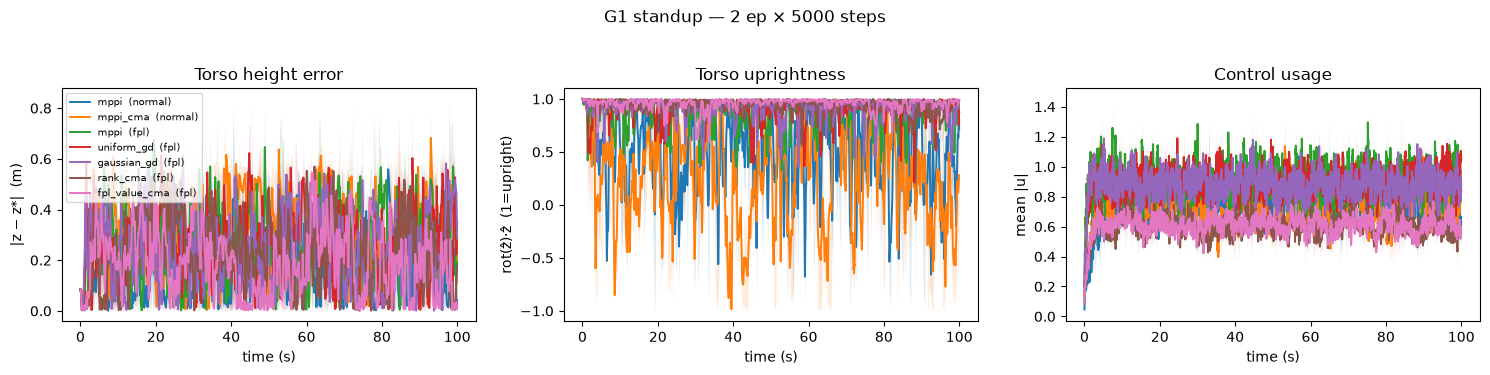

In [4]:
STEPS = 5000
N_EPISODES = 2

study = run_study(TASK, CONFIGS, steps=STEPS, n_episodes=N_EPISODES,
                  **SHARED)

plot_study(study, lambda r: g1_metrics(r, task), g1_panels(), dt=DT,
           title=f"G1 standup — {N_EPISODES} ep × {STEPS} steps")
summarize(study, lambda r: g1_metrics(r, task), ["height_err", "upright", "u_mag"])

## (optional) Render a video of one config

Set `RUN_VIDEO = True` to render an mp4 of a single config and embed it.

In [6]:
RUN_VIDEO = True
if RUN_VIDEO:
    from IPython.display import Video, display
    res = render_video(TASK, RankCMA, steps=150, out_path="/tmp/g1_rank_cma.mp4",
                       cost_mode="fpl_discounted", sigma_init=0.5, n_gd_iter=5, **SHARED)
    print(f"plan {res['plan_ms']:.1f} ms/step")
    display(Video(str(res["path"]), embed=True, width=360))
else:
    print("set RUN_VIDEO = True to render")

plan 8.0 ms/step
